# CO on a CuPd nanoparticle: relaxed energies + batched replica exchange

The production-style molecular GCMC workflow (**requires a GPU** and the MACE/nvalchemi stack):

1. a CuPd nanoparticle in a spherical insertion shell,
2. rigid CO insertion/deletion at $\mu_\mathrm{CO} = E_\mathrm{MACE}(\mathrm{CO}) + \Delta\mu$, plus Cu↔Pd permutations so the alloy can segregate under the adsorbate,
3. one replica per $\Delta\mu$, all replicas relaxed **in one batched pass per MC step** on a single GPU (`BatchedReplicaExchange` + `AlchemiFCalculator`),
4. coverage vs $\Delta\mu$ = the adsorption phase diagram, plus structure snapshots.

This notebook runs a deliberately tiny demo (38-atom particle, 3 replicas, few steps).
The committed script `examples/re_gcmc_co_cupd_batched.py` is the full version (size, ladder, convergence check all configurable).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from mcpy.utils.logging import configure as configure_logging
configure_logging()

from ase.build import molecule
from ase.cluster import Octahedron
from mcpy.moves import (MoleculeInsertionMove, MoleculeDeletionMove,
                        PermutationMove, MoveSelector)
from mcpy.ensembles.grand_canonical_ensemble import GrandCanonicalEnsemble
from mcpy.ensembles import BatchedReplicaExchange
from mcpy.calculators import AlchemiFCalculator
from mcpy.cell import SphericalCell

outdir = os.path.expanduser('~/mcpy_tmp_runs/co_cupd_notebook')
os.makedirs(outdir, exist_ok=True)

/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/torch/jit/_script.py:365: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
# Cu33Pd5 truncated octahedron ('small Pd quantity')
rng = np.random.default_rng(7)
np_atoms = Octahedron('Cu', 4, cutoff=1)
sym = np.array(np_atoms.get_chemical_symbols())
sym[rng.choice(len(np_atoms), size=5, replace=False)] = 'Pd'
np_atoms.set_chemical_symbols(sym.tolist())
np_atoms.center(vacuum=10.0)
np_atoms.pbc = False
n_metal = len(np_atoms)
np_atoms.get_chemical_formula()

'Cu33Pd5'

In [3]:
co = molecule('CO')
calc = AlchemiFCalculator(checkpoint='medium-mpa-0', steps=30, fmax=0.1,
                          compile_model=False)   # compile on for production
e_co = calc.get_potential_energy(molecule('CO', cell=[20.]*3, pbc=False))
print(f'E(CO) = {e_co:.3f} eV')

/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument


/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/mace/modules/models.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "atomic_numbers", torch.tensor(atomic_numbers, dtype=torch.int64)


E(CO) = -14.288 eV


In [4]:
delta_mus = [-1.6, -1.0, -0.4]        # coarse 3-point ladder for the demo
T = 400.0
mus = [{'CO': e_co + d} for d in delta_mus]

def gcmc_factory(mu, rank):
    atoms = np_atoms.copy()
    cell = SphericalCell(atoms, vacuum=3.5,
                         species_radii={'Cu': 2.4, 'Pd': 2.5, 'C': 0., 'O': 0.},
                         seed=100 + rank)
    ms = MoveSelector([2, 2, 1],
                      [MoleculeInsertionMove(cell, co, 'CO', seed=10 + rank, min_insert=1.3),
                       MoleculeDeletionMove(cell, co, 'CO', seed=40 + rank),
                       PermutationMove(species=['Cu', 'Pd'], seed=70 + rank)],
                      n_moves=3)
    d = delta_mus[rank]
    return GrandCanonicalEnsemble(
        atoms=atoms, cells=[cell], calculator=calc, mu=mu, units_type='metal',
        species=['Cu', 'Pd'], molecules={'CO': co}, temperature=T,
        move_selector=ms, random_seed=rank,
        outfile=os.path.join(outdir, f'gcmc_dmu_{d}.out'),
        traj_file=os.path.join(outdir, f'gcmc_dmu_{d}.xyz'),
        outfile_write_interval=1, trajectory_write_interval=1)

pt = BatchedReplicaExchange(gcmc_factory, calculator=calc, mus=mus,
                            gcmc_steps=15, exchange_interval=5,
                            write_out_interval=5, seed=1,
                            outfile=os.path.join(outdir, 're.log'),
                            global_minimum_file=os.path.join(outdir, 'gm.xyz'))
pt.run()   # ~2-4 min on a modern GPU

2026-07-07 12:13:54,799 mcpy.ensembles.base_ensemble INFO: GCMC starting: T=400.0 K, mu={'CO': -15.887687301635742}, outfile=/home/energystorage/mcpy_tmp_runs/co_cupd_notebook/gcmc_dmu_-1.6.out


2026-07-07 12:13:54,800 mcpy.ensembles.base_ensemble INFO: GCMC starting: T=400.0 K, mu={'CO': -15.287687301635742}, outfile=/home/energystorage/mcpy_tmp_runs/co_cupd_notebook/gcmc_dmu_-1.0.out


2026-07-07 12:13:54,801 mcpy.ensembles.base_ensemble INFO: GCMC starting: T=400.0 K, mu={'CO': -14.687687301635743}, outfile=/home/energystorage/mcpy_tmp_runs/co_cupd_notebook/gcmc_dmu_-0.4.out


W0707 12:13:59.464000 132021 site-packages/torch/_dynamo/convert_frame.py:1853] [1/8] torch._dynamo hit config.recompile_limit (8)
W0707 12:13:59.464000 132021 site-packages/torch/_dynamo/convert_frame.py:1853] [1/8]    function: '_rebuild' (/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/nvalchemi/hooks/neighbor_list.py:220)
W0707 12:13:59.464000 132021 site-packages/torch/_dynamo/convert_frame.py:1853] [1/8]    last reason: 1/5: list(dict.keys(batch._storage.groups))[1] == 'system'    # for group in self._storage.groups.values():  # nvalchemi/data/batch.py:941 in _get_attr
W0707 12:13:59.464000 132021 site-packages/torch/_dynamo/convert_frame.py:1853] [1/8] User stack trace:
W0707 12:13:59.464000 132021 site-packages/torch/_dynamo/convert_frame.py:1853] [1/8]   File "/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/nvalchemi/hooks/neighbor_list.py", line 222, in _rebuild
W0707 12:13:59.464000 132021 site-packages/torch/_dynamo/convert_

2026-07-07 12:14:18,606 mcpy.ensembles.base_ensemble INFO: GCMC complete: steps=15, final_energy=-133.604675 eV


...

2026-07-07 12:14:18,614 mcpy.ensembles.base_ensemble INFO: GCMC complete: steps=15, final_energy=-224.865173 eV


2026-07-07 12:14:18,615 mcpy.ensembles.base_ensemble INFO: Simulation complete.


2026-07-07 12:14:18,615 mcpy.ensembles.base_ensemble INFO: Total attempts per move: [13, 18, 14]


2026-07-07 12:14:18,615 mcpy.ensembles.base_ensemble INFO: Cumulative acceptance ratios: [0.8461538461538461, 0.11764705882352941, 0.6428571428571429]


2026-07-07 12:14:18,616 mcpy.ensembles.base_ensemble INFO: Final energy (eV): -224.865173


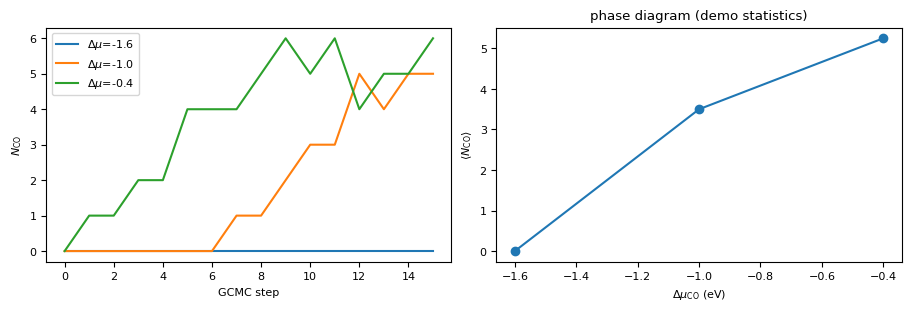

In [5]:
def coverage(d):
    ns = []
    with open(os.path.join(outdir, f'gcmc_dmu_{d}.out')) as f:
        for line in f:
            s = line.split()
            if s and s[0].isdigit():
                ns.append((int(s[1]) - n_metal) / 2)
    return ns

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3), constrained_layout=True)
for d in delta_mus:
    a1.plot(coverage(d), label=f'$\\Delta\\mu$={d}')
a1.set(xlabel='GCMC step', ylabel=r'$N_\mathrm{CO}$'); a1.legend()
cov = [np.mean(coverage(d)[len(coverage(d))//2:]) for d in delta_mus]
a2.plot(delta_mus, cov, 'o-')
a2.set(xlabel=r'$\Delta\mu_\mathrm{CO}$ (eV)', ylabel=r'$\langle N_\mathrm{CO}\rangle$',
       title='phase diagram (demo statistics)')
plt.show()

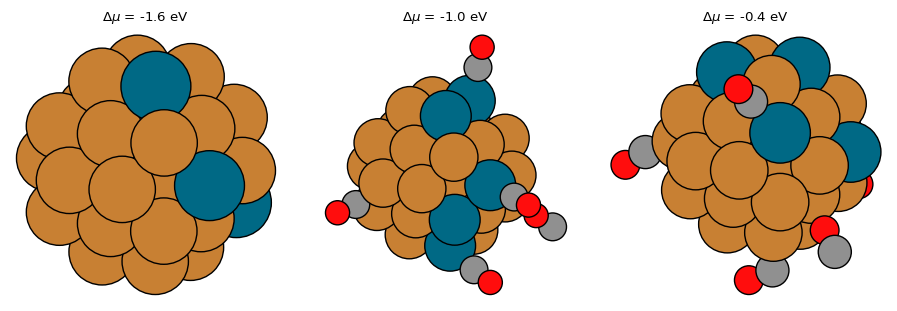

In [6]:
# structure snapshots: one per replica (Cu brown, Pd teal, C grey, O red)
import ase.io
from ase.visualize.plot import plot_atoms
fig, axes = plt.subplots(1, len(delta_mus), figsize=(9, 3), constrained_layout=True)
for ax, d in zip(axes, delta_mus):
    last = ase.io.read(os.path.join(outdir, f'gcmc_dmu_{d}.xyz'), index=-1)
    plot_atoms(last, ax, rotation='12z,-75x', show_unit_cell=0)
    ax.set_title(f'$\\Delta\\mu$ = {d} eV'); ax.set_axis_off()
plt.show()

**Reading the result**: coverage rises with $\Delta\mu$; at low coverage CO decorates the Pd sites first (stronger binding), which together with the Cu↔Pd permutation move drives Pd toward CO-covered surface positions.

**Production settings** (see `examples/re_gcmc_co_cupd_batched.py`):
a denser $\Delta\mu$ ladder in the rising part of the isotherm (avoid the saturated plateau, it carries no information), hundreds of GCMC steps with the built-in stationarity check, `--octa-length 9 --octa-cutoff 3` for a 405-atom particle, and `compile_model=True` for ~2x faster forwards.
The sampler and potential behind all of this are cross-validated against LAMMPS: `benchmark/README.md`.